# 🏙️ Notebook 01 · Exploración y Análisis Descriptivo
---
**Proyecto:** Bogotá — Análisis Predictivo del Mercado Inmobiliario Urbano  
**Fuente:** UAECD / IDECA · 2020–2026  
**Autor:** Kevin Palacio 

---
## 🎯 Objetivo

Realizar un análisis exploratorio completo de los datos de valor comercial  
por m² a nivel de manzana, identificando patrones, anomalías y decisiones  
metodológicas que guiarán los modelos predictivos posteriores.

## 📋 Contenido

| Sección | Descripción |
|---|---|
| 1 | Carga de datos desde PostGIS |
| 2 | Estadísticas descriptivas por año |
| 3 | Distribución de valores por localidad |
| 4 | Detección de valores atípicos |
| 5 | Análisis por tipo de territorio |
| 6 | Cobertura geográfica y casos especiales |
| 7 | Imputación de valores y exportación |

---
## ⚙️ Sección 1 · Configuración y carga de datos

> Conexión a PostgreSQL + PostGIS y carga del dataset principal.  
> Se incluye la columna `tipo_territorio` (urbano / periurbano / rural)  
> resultado del join espacial con la capa de microterritorios rurales UAECD.

In [ ]:
import sys
sys.path.append('../src')

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
from db_config import DB_URL

# Configuración visual
pd.set_option('display.float_format', '{:,.0f}'.format)
pd.set_option('display.max_columns', 20)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

engine = create_engine(DB_URL)
print("✓ Conexión a base de datos establecida")

✓ Conexión a base de datos establecida


In [ ]:
# ── Sección 1. Carga de datos desde PostGIS (actualizada(adicion de columna "tipo_territorio")) ─────

query = """
    SELECT 
        id, anio, cod_manzana, valor_mediano,
        localidad, cod_localidad, sector,
        es_rural, tipo_territorio
    FROM catastro.valor_manzana
    ORDER BY anio, localidad;
"""

df = pd.read_sql(query, engine)

resumen_territorio = df.drop_duplicates(subset=['id']).groupby('tipo_territorio').agg(
    manzanas=('id', 'count'),
    valor_mediano_promedio=('valor_mediano', 'median')
).reset_index()

print(f"✓ Registros cargados  : {len(df):,}")
print(f"✓ Años disponibles    : {sorted(df['anio'].unique())}")
print(f"✓ Localidades         : {df['localidad'].nunique()}")
print(f"✓ Manzanas únicas     : {df['cod_manzana'].nunique():,}")
print(f"\n── Distribución por tipo de territorio ──────────────────")
display(resumen_territorio)

✓ Registros cargados  : 299,482
✓ Años disponibles    : [2020, 2021, 2022, 2023, 2024, 2025, 2026]
✓ Localidades         : 20
✓ Manzanas únicas     : 44,100

── Distribución por tipo de territorio ──────────────────


,tipo_territorio,manzanas,valor_mediano_promedio
0,periurbano,1724,"375,380"
1,rural,1362,"7,668"
2,urbano,296396,"2,050,000"


---
## 📈 Sección 2 · Estadísticas descriptivas por año

> Evolución del valor comercial por m² entre 2020 y 2026.  
> Se calcula la variación porcentual anual sobre la mediana para evitar  
> el efecto de valores extremos en el promedio.

── Resumen estadístico por año ──────────────────────────


,anio,registros,valor_minimo,valor_promedio,valor_mediana,valor_maximo,desviacion,variacion_pct
0,2020,43907,0,"1,703,259","1,625,000","27,800,000","1,194,536",NaN
1,2021,43958,0,"1,865,565","1,800,000","28,500,000","1,314,708",11
2,2022,41584,"8,300","1,971,835","1,900,000","28,500,000","1,271,609",6
3,2023,42096,800,"2,072,498","2,050,000","28,500,000","1,325,924",8
4,2024,42036,"3,800","2,220,722","2,150,000","28,500,000","1,380,381",5
5,2025,44043,0,"2,271,757","2,300,000","30,940,000","1,507,888",7
6,2026,41858,"4,000","2,625,473","2,590,000","30,300,000","1,601,585",13


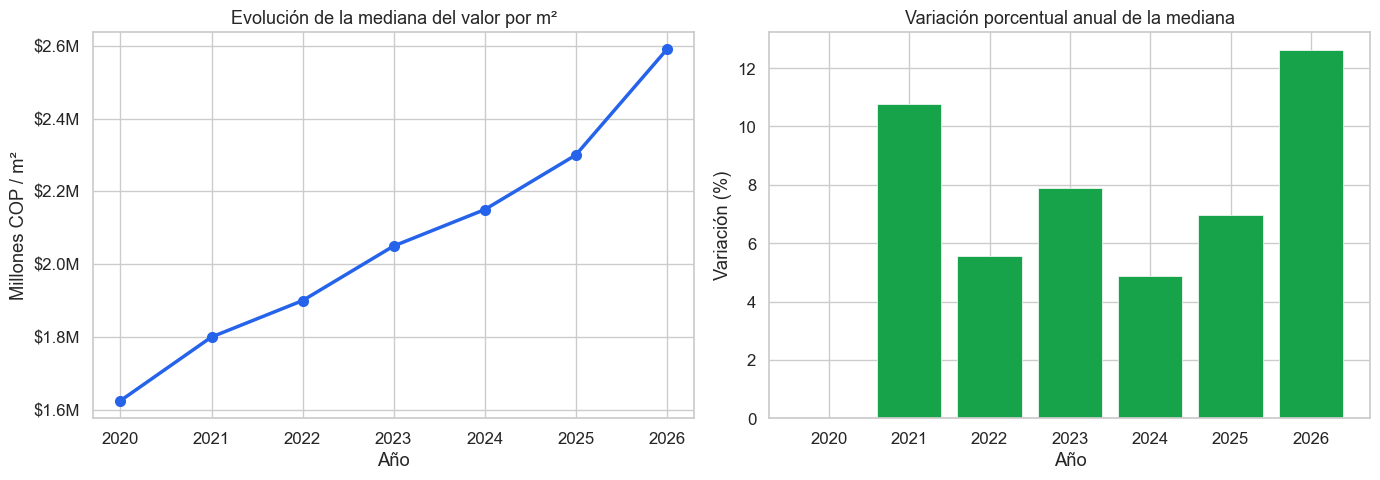

✓ Gráfico guardado en reports/figures/


In [14]:
# ── Sección 2. Estadísticas descriptivas por año ─────────────

resumen_anual = df.groupby('anio')['valor_mediano'].agg(
    registros='count',
    valor_minimo='min',
    valor_promedio='mean',
    valor_mediana='median',
    valor_maximo='max',
    desviacion='std'
).reset_index()

resumen_anual['variacion_pct'] = (
    resumen_anual['valor_mediana'].pct_change() * 100
).round(2)

print("── Resumen estadístico por año ──────────────────────────")
display(resumen_anual)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    resumen_anual['anio'], resumen_anual['valor_mediana'] / 1_000_000,
    marker='o', linewidth=2.5, color='#2563EB', markersize=7
)
axes[0].set_title('Evolución de la mediana del valor por m²', fontsize=13)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Millones COP / m²')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fM'))

colores = ['#16A34A' if v >= 0 else '#DC2626'
           for v in resumen_anual['variacion_pct'].fillna(0)]
axes[1].bar(
    resumen_anual['anio'], resumen_anual['variacion_pct'].fillna(0),
    color=colores, edgecolor='white', linewidth=0.5
)
axes[1].set_title('Variación porcentual anual de la mediana', fontsize=13)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Variación (%)')
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('../reports/figures/01_evolucion_valor_anual.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado en reports/figures/")

---
## 🗺️ Sección 3 · Distribución de valores por localidad

> Ranking y mapa de calor del valor mediano por localidad y año.  
> Las localidades están ordenadas de menor a mayor valor en 2026  
> para facilitar la lectura de la evolución temporal.

> ⚠️ **Nota:** La localidad de **Sumapaz** no aparece en este análisis  
> porque la UAECD no registra valor catastral en suelo rural.  
> Sumapaz es 100% rural y está fuera del alcance del dataset.

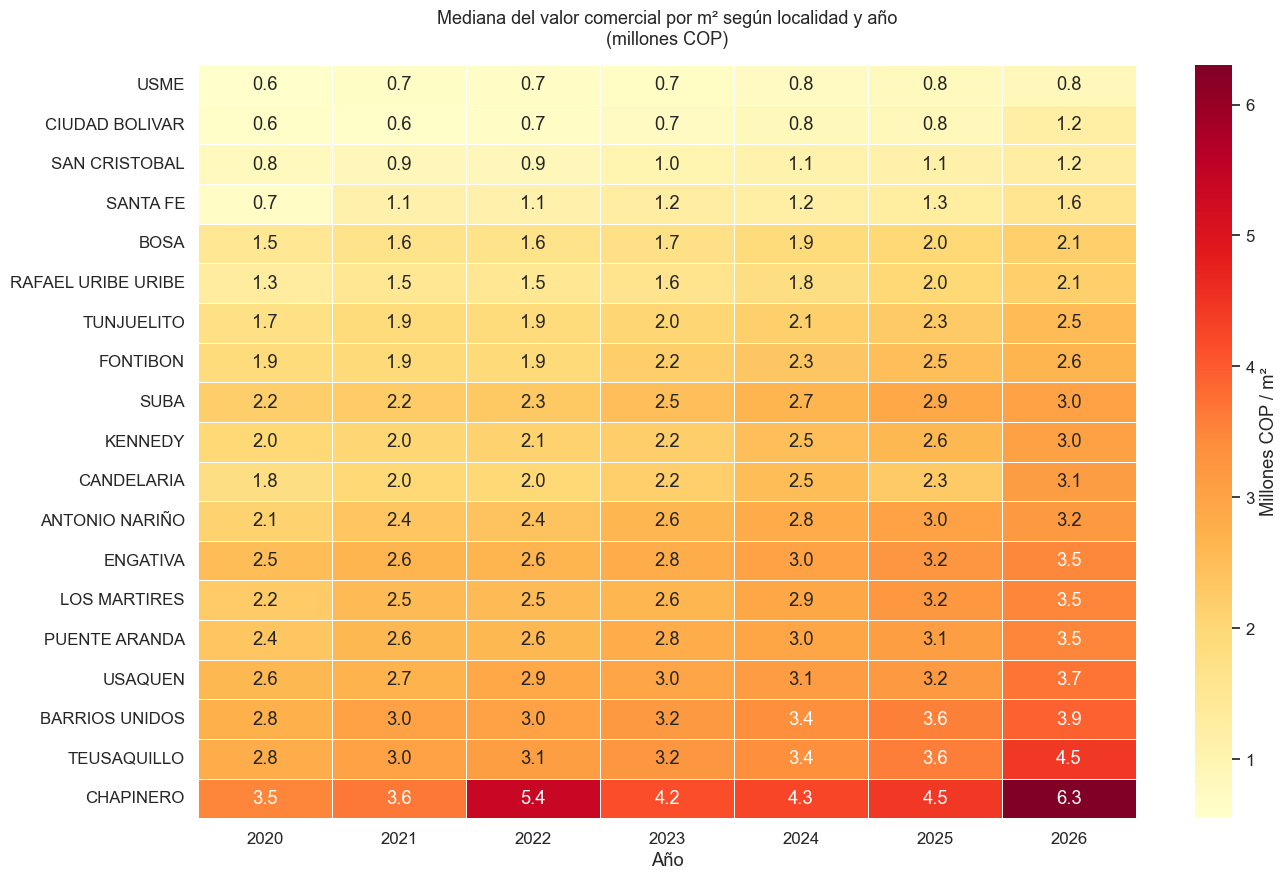


── Ranking de localidades por valor mediano (2026) ──────


,localidad,mediana,promedio,manzanas
0,CHAPINERO,"6,300,000","5,666,026",1050
1,TEUSAQUILLO,"4,450,000","4,324,307",979
2,BARRIOS UNIDOS,"3,940,000","3,909,127",1178
3,USAQUEN,"3,700,000","3,728,561",2242
4,PUENTE ARANDA,"3,510,000","3,414,403",1735
5,LOS MARTIRES,"3,500,000","3,679,871",698
6,ENGATIVA,"3,474,000","3,237,400",4116
7,ANTONIO NARIÑO,"3,200,000","3,157,933",588
8,CANDELARIA,"3,111,000","2,952,348",180
9,KENNEDY,"3,050,000","3,027,259",4767


✓ Gráfico guardado en reports/figures/


In [ ]:
# ── Sección 3. Distribución de valores por localidad ─────────

valor_localidad = df.groupby(['localidad', 'anio'])['valor_mediano'].median().reset_index()

orden_localidades = (
    valor_localidad[valor_localidad['anio'] == 2026]
    .sort_values('valor_mediano', ascending=True)['localidad']
    .tolist()
)

pivot = valor_localidad.pivot(index='localidad', columns='anio', values='valor_mediano')
pivot = pivot.loc[orden_localidades]

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    pivot / 1_000_000,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white', ax=ax,
    cbar_kws={'label': 'Millones COP / m²'}
)
ax.set_title('Mediana del valor comercial por m² según localidad y año\n(millones COP)',
             fontsize=13, pad=15)
ax.set_xlabel('Año')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../reports/figures/02_heatmap_localidad_anio.png', dpi=150, bbox_inches='tight')
plt.show()

ranking_2026 = (
    df[df['anio'] == 2026]
    .groupby('localidad')['valor_mediano']
    .agg(mediana='median', promedio='mean', manzanas='count')
    .sort_values('mediana', ascending=False)
    .reset_index()
)
ranking_2026['mediana'] = ranking_2026['mediana'].map('{:,.0f}'.format)
ranking_2026['promedio'] = ranking_2026['promedio'].map('{:,.0f}'.format)

print("\n── Ranking de localidades por valor mediano (2026) ──────")
display(ranking_2026)
print("✓ Gráfico guardado en reports/figures/")

---
## 🔍 Sección 4 · Detección de valores atípicos

> Identificación de outliers mediante el método IQR (rango intercuartílico).  
> Un valor se considera atípico si cae fuera del rango  
> `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`.

> 💡 **Hallazgo anticipado:** Santa Fe presenta la mayor brecha entre mediana  
> y promedio del ranking, indicando alta heterogeneidad interna —  
> pocas manzanas de alto valor jalan el promedio hacia arriba.

── Manzanas con valor_mediano = 0 por año ───────────────


,anio,manzanas_en_cero
0,2020,1133
1,2021,2371
2,2025,2159



── Manzanas sin localidad asignada por año ──────────────


,anio,sin_localidad
0,2020,5
1,2021,5
2,2023,5
3,2024,4
4,2025,4
5,2026,4



── Outliers por año (método IQR) ────────────────────────


,anio,limite_inferior,limite_superior,outliers_count,outliers_pct
0,2020,"-1,600,000","4,800,000",704,2
1,2021,"-1,700,000","5,180,000",801,2
2,2022,"-1,225,000","4,975,000",962,2
3,2023,"-1,450,000","5,350,000",813,2
4,2024,"-1,555,000","5,685,000",768,2
5,2025,"-2,050,000","6,350,000",740,2
6,2026,"-1,550,000","6,530,000",787,2


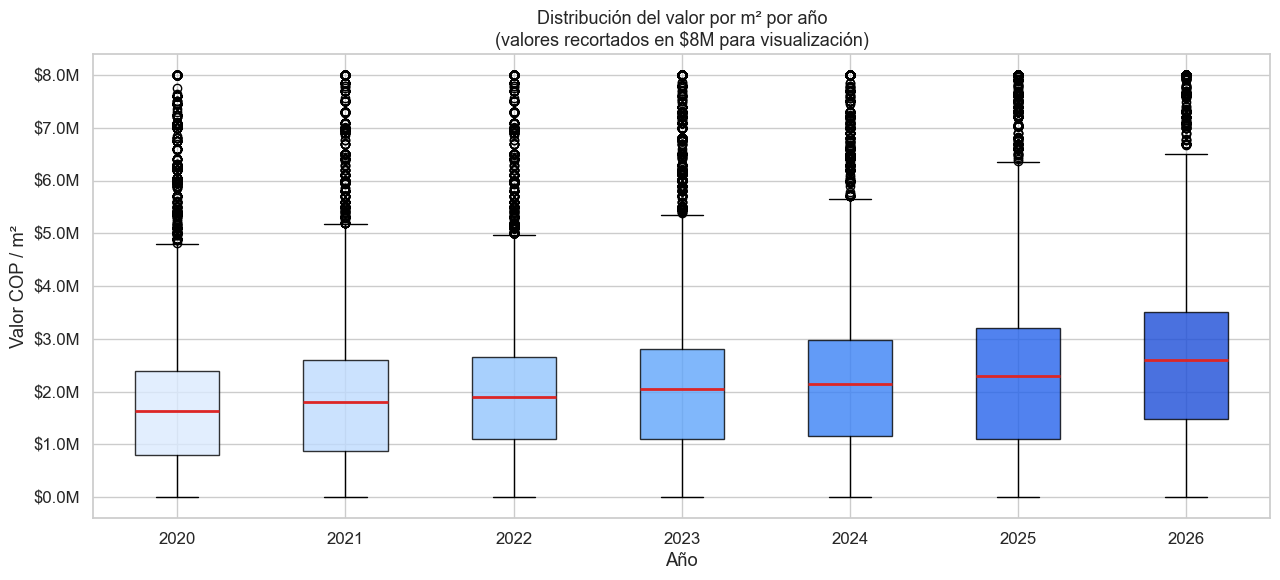

✓ Gráfico guardado en reports/figures/


In [15]:
# ── Sección 4. Detección de valores atípicos ─────────────────

ceros = df[df['valor_mediano'] == 0].groupby('anio').size().reset_index(name='manzanas_en_cero')
print("── Manzanas con valor_mediano = 0 por año ───────────────")
display(ceros)

sin_localidad = df[df['localidad'].isna()].groupby('anio').size().reset_index(name='sin_localidad')
print("\n── Manzanas sin localidad asignada por año ──────────────")
display(sin_localidad)

def detectar_outliers_iqr(grupo):
    q1 = grupo['valor_mediano'].quantile(0.25)
    q3 = grupo['valor_mediano'].quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = grupo[
        (grupo['valor_mediano'] < limite_inf) |
        (grupo['valor_mediano'] > limite_sup)
    ]
    return pd.Series({
        'limite_inferior':  limite_inf,
        'limite_superior':  limite_sup,
        'outliers_count':   len(outliers),
        'outliers_pct':     round(len(outliers) / len(grupo) * 100, 2)
    })

outliers_anual = df.groupby('anio').apply(
    detectar_outliers_iqr, include_groups=False
).reset_index()
print("\n── Outliers por año (método IQR) ────────────────────────")
display(outliers_anual)

fig, ax = plt.subplots(figsize=(13, 6))
datos_box = [
    df[df['anio'] == anio]['valor_mediano'].clip(upper=8_000_000).values
    for anio in sorted(df['anio'].unique())
]
bp = ax.boxplot(datos_box, patch_artist=True, notch=False,
                medianprops=dict(color='#DC2626', linewidth=2))

colores_box = ['#DBEAFE','#BFDBFE','#93C5FD','#60A5FA','#3B82F6','#2563EB','#1D4ED8']
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticklabels(sorted(df['anio'].unique()))
ax.set_title('Distribución del valor por m² por año\n(valores recortados en $8M para visualización)', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('Valor COP / m²')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('../reports/figures/03_boxplot_outliers_anual.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado en reports/figures/")

---
## 🌍 Sección 5 · Análisis por tipo de territorio

> Comparación estadística entre zonas **urbanas**, **periurbanas** y **rurales**.  
> La clasificación se basó en la intersección espacial con la capa de  
> microterritorios rurales UAECD (actualizada agosto 2023).

> ⚠️ **Limitación metodológica:** El salto en cobertura rural de 9 manzanas  
> en 2022 a 191 en 2023 refleja la actualización de la capa de microterritorios,  
> no un cambio real en el territorio.


▸ URBANO


,anio,manzanas,minimo,mediana,promedio,maximo,coef_variacion
0,2020,42549,"6,600","1,700,000","1,754,947","27,800,000",67
1,2021,41388,"8,300","1,900,000","1,978,206","28,500,000",64
2,2022,41385,"8,300","1,900,000","1,978,114","28,500,000",64
3,2023,41675,"9,100","2,100,000","2,090,266","28,500,000",63
4,2024,41645,"9,100","2,160,000","2,237,734","28,500,000",61
5,2025,41511,"9,600","2,360,000","2,406,113","30,940,000",60
6,2026,41481,"4,000","2,600,000","2,644,245","30,300,000",60



▸ PERIURBANO


,anio,manzanas,minimo,mediana,promedio,maximo,coef_variacion
0,2020,210,"6,900","349,500","535,717","5,400,000",136
1,2021,190,"8,300","440,000","688,046","6,000,000",116
2,2022,190,"8,300","440,000","688,046","6,000,000",116
3,2023,230,800,"325,836","508,860","6,200,000",142
4,2024,224,"12,700","475,000","654,045","6,600,000",115
5,2025,224,"5,680","600,000","712,053","7,030,000",109
6,2026,230,"12,600","697,478","834,651","8,680,000",115



▸ RURAL


,anio,manzanas,minimo,mediana,promedio,maximo,coef_variacion
0,2020,15,"9,700","106,000","84,940","160,000",62
1,2021,9,"12,200","138,400","199,530","800,000",123
2,2022,9,"12,200","138,400","199,530","800,000",123
3,2023,191,800,"49,400","78,519","363,910",79
4,2024,167,"3,800","49,400","79,874","176,727",74
5,2025,149,"12,290","110,700","102,990","198,200",72
6,2026,147,"12,600","125,050","130,450","1,694,242",114


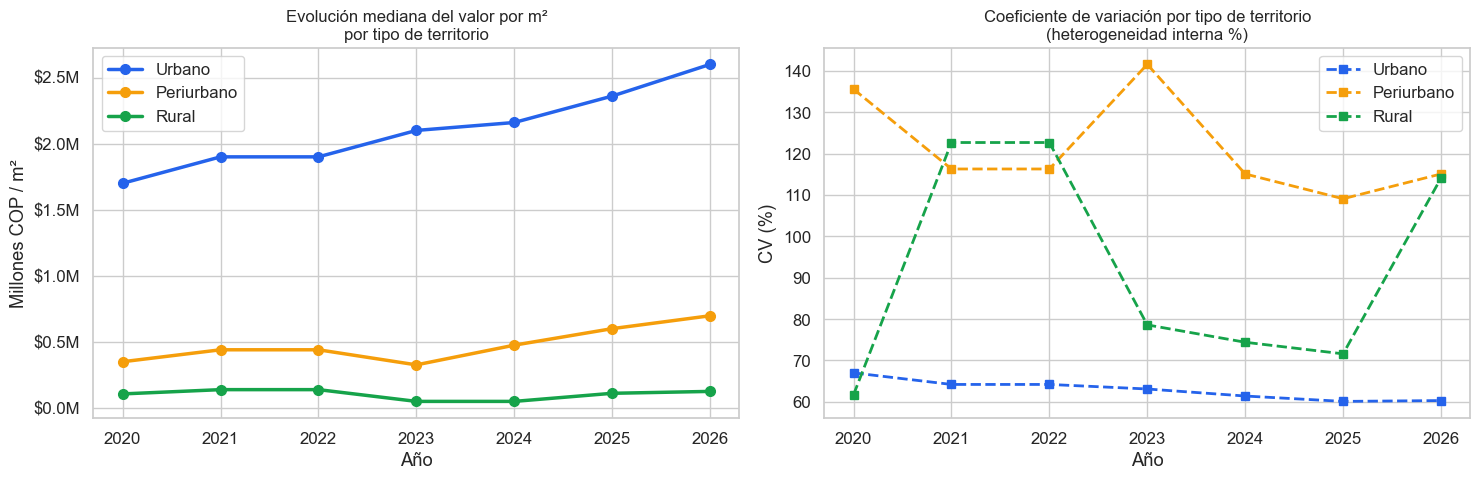


── Brecha de valor urbano vs periurbano ─────────────────


,anio,periurbano,urbano,brecha_pct
0,2020,"349,500","1,700,000",386
1,2021,"440,000","1,900,000",332
2,2022,"440,000","1,900,000",332
3,2023,"325,836","2,100,000",544
4,2024,"475,000","2,160,000",355
5,2025,"600,000","2,360,000",293
6,2026,"697,478","2,600,000",273


✓ Gráfico guardado en reports/figures/


In [16]:
# ── Análisis estadístico por tipo de territorio ───────────────

# Excluir valores en cero para estadísticas limpias
df_sin_ceros = df[df['valor_mediano'] > 0].copy()

stats_territorio = df_sin_ceros.groupby(
    ['tipo_territorio', 'anio']
)['valor_mediano'].agg(
    manzanas='count',
    minimo='min',
    mediana='median',
    promedio='mean',
    maximo='max',
    coef_variacion=lambda x: round(x.std() / x.mean() * 100, 1)
).reset_index()

for territorio in ['urbano', 'periurbano', 'rural']:
    print(f"\n▸ {territorio.upper()}")
    display(stats_territorio[
        stats_territorio['tipo_territorio'] == territorio
    ].drop(columns='tipo_territorio').reset_index(drop=True))

colores_territorio = {
    'urbano':    '#2563EB',
    'periurbano':'#F59E0B',
    'rural':     '#16A34A'
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for territorio, color in colores_territorio.items():
    datos = stats_territorio[stats_territorio['tipo_territorio'] == territorio]
    axes[0].plot(
        datos['anio'], datos['mediana'] / 1_000_000,
        marker='o', linewidth=2.5, color=color,
        markersize=7, label=territorio.capitalize()
    )

axes[0].set_title('Evolución mediana del valor por m²\npor tipo de territorio', fontsize=12)
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Millones COP / m²')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
axes[0].legend()

for territorio, color in colores_territorio.items():
    datos = stats_territorio[stats_territorio['tipo_territorio'] == territorio]
    axes[1].plot(
        datos['anio'], datos['coef_variacion'],
        marker='s', linewidth=2, color=color,
        markersize=6, linestyle='--', label=territorio.capitalize()
    )

axes[1].set_title('Coeficiente de variación por tipo de territorio\n(heterogeneidad interna %)', fontsize=12)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('CV (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/04_stats_tipo_territorio.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n── Brecha de valor urbano vs periurbano ─────────────────")
brecha = stats_territorio[
    stats_territorio['tipo_territorio'].isin(['urbano','periurbano'])
].pivot(index='anio', columns='tipo_territorio', values='mediana').reset_index()
brecha['brecha_pct'] = (
    (brecha['urbano'] - brecha['periurbano']) / brecha['periurbano'] * 100
).round(1)
brecha.columns.name = None
display(brecha)
print("✓ Gráfico guardado en reports/figures/")

---
## 📋 Hallazgos clave — Análisis descriptivo y territorial

> Síntesis de los principales resultados obtenidos en las secciones 2, 3 y 4.

| # | Hallazgo | Detalle |
|---|---|---|
| 1 | **Valorización acumulada urbana** | +59% entre 2020 y 2026 · mediana $1.625M → $2.600M por m² |
| 2 | **Año de mayor aceleración** | 2026 con +13% anual |
| 3 | **Homogeneización urbana** | Coeficiente de variación bajó de 67% → 60% · zonas rezagadas convergen |
| 4 | **Brecha urbano / periurbano** | Se redujo de 386% → 273% · señal de presión de expansión urbana |
| 5 | **Zonas periurbanas** | Se valorizan más rápido que el promedio urbano desde 2023 |
| 6 | **Cobertura rural** | Salta de 9 → 191 manzanas en 2023 por actualización de capa UAECD (ago 2023) |
| 7 | **Sumapaz** | Sin registros catastrales · localidad 100% rural fuera del alcance de la UAECD |


---
## 🔎 Sección 6 · Cobertura geográfica y casos especiales

> Revisión de dos tipos de registros que requieren tratamiento especial  
> antes de entrenar cualquier modelo predictivo:
>
> - **Manzanas con `valor_mediano = 0`** — posibles errores de registro,  
>   predios en incorporación catastral o zonas de restricción de uso
> - **Manzanas sin localidad asignada** — 5 manzanas únicas que no  
>   intersectaron con ningún polígono de localidad en el join espacial
>
> Ambos grupos fueron exportados como `.gpkg` para validación visual en QGIS.

In [17]:
# ── Sección 6. Cobertura geográfica y casos especiales ────────

sin_localidad = df[df['localidad'].isna()].copy()

print(f"▸ Total registros sin localidad : {len(sin_localidad):,}")
print(f"▸ Manzanas únicas sin localidad : {sin_localidad['cod_manzana'].nunique():,}")
print(f"▸ Tipo de territorio            :\n"
      f"{sin_localidad['tipo_territorio'].value_counts().to_string()}")

ceros = df[df['valor_mediano'] == 0].copy()

print(f"\n▸ Total registros con valor = 0 : {len(ceros):,}")
print(f"▸ Distribución por año         :\n"
      f"{ceros.groupby('anio').size().to_string()}")
print(f"\n▸ Distribución por tipo de territorio :\n"
      f"{ceros.groupby('tipo_territorio').size().to_string()}")

ceros_localidad = (
    ceros[ceros['localidad'].notna()]
    .groupby(['localidad', 'tipo_territorio'])
    .size()
    .reset_index(name='registros_en_cero')
    .sort_values('registros_en_cero', ascending=False)
    .head(10)
)
print(f"\n▸ Top 10 localidades con valores en cero :")
display(ceros_localidad)

print("\n── Criterio de tratamiento ──────────────────────────────")
print("  ▸ Valor = 0 en zona urbana/periurbana → imputar con mediana del sector y año")
print("  ▸ Valor = 0 en zona rural             → conservar, puede ser suelo no valorado")
print("  ▸ Sin localidad                       → validación en QGIS · asignación por proximidad")

▸ Total registros sin localidad : 27
▸ Manzanas únicas sin localidad : 5
▸ Tipo de territorio            :
tipo_territorio
urbano    27

▸ Total registros con valor = 0 : 5,663
▸ Distribución por año         :
anio
2020    1133
2021    2371
2025    2159

▸ Distribución por tipo de territorio :
tipo_territorio
periurbano     226
rural          675
urbano        4762

▸ Top 10 localidades con valores en cero :


,localidad,tipo_territorio,registros_en_cero
9,CIUDAD BOLIVAR,urbano,1022
12,KENNEDY,urbano,556
32,USME,urbano,449
23,SUBA,urbano,433
2,BOSA,urbano,381
6,CHAPINERO,urbano,337
10,ENGATIVA,urbano,271
18,SAN CRISTOBAL,urbano,261
15,RAFAEL URIBE URIBE,urbano,224
29,USAQUEN,urbano,186



── Criterio de tratamiento ──────────────────────────────
  ▸ Valor = 0 en zona urbana/periurbana → imputar con mediana del sector y año
  ▸ Valor = 0 en zona rural             → conservar, puede ser suelo no valorado
  ▸ Sin localidad                       → validación en QGIS · asignación por proximidad


In [10]:
# ── Exportar casos especiales para validación en QGIS ─────────

from sqlalchemy import text

# Consulta espacial — incluye geometría
query_casos = """
    SELECT 
        id,
        anio,
        cod_manzana,
        valor_mediano,
        localidad,
        tipo_territorio,
        sector,
        ST_AsText(geom) as wkt
    FROM catastro.valor_manzana
    WHERE localidad IS NULL
       OR valor_mediano = 0
    ORDER BY localidad NULLS FIRST, anio;
"""

df_casos = pd.read_sql(query_casos, engine)

# Separar en dos grupos
df_sin_localidad = df_casos[df_casos['localidad'].isna()].copy()
df_valor_cero    = df_casos[df_casos['valor_mediano'] == 0].copy()

# Exportar como GeoPackage para QGIS
import geopandas as gpd
from shapely import wkt

def df_a_geodataframe(df_input):
    gdf = df_input.copy()
    gdf['geometry'] = gdf['wkt'].apply(wkt.loads)
    gdf = gdf.drop(columns=['wkt'])
    return gpd.GeoDataFrame(gdf, geometry='geometry', crs='EPSG:4326')

gdf_sin_localidad = df_a_geodataframe(df_sin_localidad)
gdf_valor_cero    = df_a_geodataframe(df_valor_cero)

ruta_sin_localidad = '../data/processed/validacion_sin_localidad.gpkg'
ruta_valor_cero    = '../data/processed/validacion_valor_cero.gpkg'

gdf_sin_localidad.to_file(ruta_sin_localidad, driver='GPKG')
gdf_valor_cero.to_file(ruta_valor_cero,    driver='GPKG')

print(f"✓ Sin localidad  : {len(gdf_sin_localidad):,} registros → {ruta_sin_localidad}")
print(f"✓ Valor en cero  : {len(gdf_valor_cero):,} registros → {ruta_valor_cero}")


✓ Sin localidad  : 27 registros → ../data/processed/validacion_sin_localidad.gpkg
✓ Valor en cero  : 5,663 registros → ../data/processed/validacion_valor_cero.gpkg


---
## 🔧 Sección 7 · Imputación de valores y cierre del EDA

> **Criterios aplicados:**
> - `valor_mediano = 0` en zona **urbana y periurbana** → mediana del sector y año
> - `valor_mediano = 0` en zona **rural** → se conserva, se marca como no imputado
> - **Sin localidad** → pendiente validación QGIS · se asigna por proximidad espacial
>
> Se agrega columna `valor_imputado (bool)` para trazabilidad en modelos posteriores.

In [11]:
# ── Sección 6. Imputación de valores ─────────────────────────

# Limpiar columnas residuales de ejecuciones anteriores
cols_limpiar = ['mediana_sector', 'mediana_localidad', 
                'valor_imputado', 'valor_final']
df = df.drop(columns=[c for c in cols_limpiar if c in df.columns])

# 6.1 — Calcular medianas de referencia
mediana_sector = (
    df[(df['valor_mediano'] > 0) & (df['tipo_territorio'].isin(['urbano','periurbano']))]
    .groupby(['sector', 'anio'])['valor_mediano']
    .median()
    .reset_index()
    .rename(columns={'valor_mediano': 'mediana_sector'})
)

mediana_localidad = (
    df[(df['valor_mediano'] > 0) & (df['tipo_territorio'].isin(['urbano','periurbano']))]
    .groupby(['localidad', 'anio'])['valor_mediano']
    .median()
    .reset_index()
    .rename(columns={'valor_mediano': 'mediana_localidad'})
)

# 6.2 — Unir medianas al dataframe
df = df.merge(mediana_sector,    on=['sector', 'anio'],    how='left')
df = df.merge(mediana_localidad, on=['localidad', 'anio'], how='left')

# 6.3 — Aplicar imputación
df['valor_imputado'] = False
df['valor_final']    = df['valor_mediano'].copy()

mask_imputable = (
    (df['valor_mediano'] == 0) &
    (df['tipo_territorio'].isin(['urbano', 'periurbano']))
)

df.loc[mask_imputable, 'valor_final'] = df.loc[mask_imputable].apply(
    lambda r: r['mediana_sector'] if pd.notna(r['mediana_sector'])
              else r['mediana_localidad'],
    axis=1
)
df.loc[mask_imputable, 'valor_imputado'] = True

# 6.4 — Verificación
total_imputados = df['valor_imputado'].sum()
aun_en_cero     = (df['valor_final'] == 0).sum()

print(f"▸ Registros imputados     : {total_imputados:,}")
print(f"▸ Registros aún en cero   : {aun_en_cero:,} (zona rural, esperado)")
print(f"\n── Distribución de imputados por año ────────────────────")
display(
    df[df['valor_imputado']].groupby('anio').size()
    .reset_index(name='imputados')
)

▸ Registros imputados     : 4,988
▸ Registros aún en cero   : 675 (zona rural, esperado)

── Distribución de imputados por año ────────────────────


,anio,imputados
0,2020,863
1,2021,2093
2,2025,2032


In [12]:
df_export = df[[
    'id', 'anio', 'cod_manzana', 'localidad', 'cod_localidad',
    'sector', 'tipo_territorio', 'es_rural',
    'valor_mediano', 'valor_final', 'valor_imputado'
]].copy()

df_export.to_parquet('../data/processed/valor_manzana_limpio.parquet', index=False)
print(f"✓ Dataset limpio exportado → data/processed/valor_manzana_limpio.parquet")
print(f"▸ Registros totales : {len(df_export):,}")
print(f"▸ Columnas          : {list(df_export.columns)}")

✓ Dataset limpio exportado → data/processed/valor_manzana_limpio.parquet
▸ Registros totales : 299,482
▸ Columnas          : ['id', 'anio', 'cod_manzana', 'localidad', 'cod_localidad', 'sector', 'tipo_territorio', 'es_rural', 'valor_mediano', 'valor_final', 'valor_imputado']
